# 04. Media Deep Dive

This notebook interprets the fitted MMM through:

1. posterior media parameters;
2. saturation response curves;
3. channel contributions;
4. historical ROAS;
5. marginal ROAS from a 1% spend increase.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from pymc_marketing.mmm.multidimensional import MMM


root = Path("..")

mmm = MMM.load(
    root / "artifacts/mmm_regularized_with_ppc.nc"
)

df = pd.read_csv(
    root / "data/scenario_a/scenario_a_train.csv",
    parse_dates=["date_week"],
)

post = mmm.idata.posterior
channels = post.channel.values.tolist()

names = {
    c: c.removesuffix("_spend").replace("_", " ").title()
    for c in channels
}

y_scale = df["revenue"].abs().max()
x_scale = df[channels].abs().max()

# Original revenue scale
contribution = post["channel_contribution"] * y_scale

print(channels)

['tv_spend', 'google_search_spend', 'tiktok_spend']


## Posterior Media Parameters

- `adstock_alpha` controls carryover persistence.
- `saturation_lam` controls how quickly diminishing returns occur.
- `saturation_beta` controls the maximum contribution scale.

A larger alpha means slower decay and stronger carryover.

In [3]:
parameter_summary = pd.DataFrame(
    {
        "alpha": post["adstock_alpha"]
        .median(("chain", "draw"))
        .values,

        "lambda": post["saturation_lam"]
        .median(("chain", "draw"))
        .values,

        "beta_revenue_scale": (
            post["saturation_beta"] * y_scale
        )
        .median(("chain", "draw"))
        .values,
    },
    index=[names[c] for c in channels],
)

parameter_summary.round(3)

,alpha,lambda,beta_revenue_scale
Tv,0.364,2.586,112.934
Google Search,0.212,2.881,97.929
Tiktok,0.151,2.432,71.066


## Saturation Response Curves

The logistic saturation function represents diminishing returns.

The solid line is the posterior median, and the shaded region is the central 94% credible interval.

The vertical dotted line is the maximum spend observed in training. Values beyond it are extrapolations.

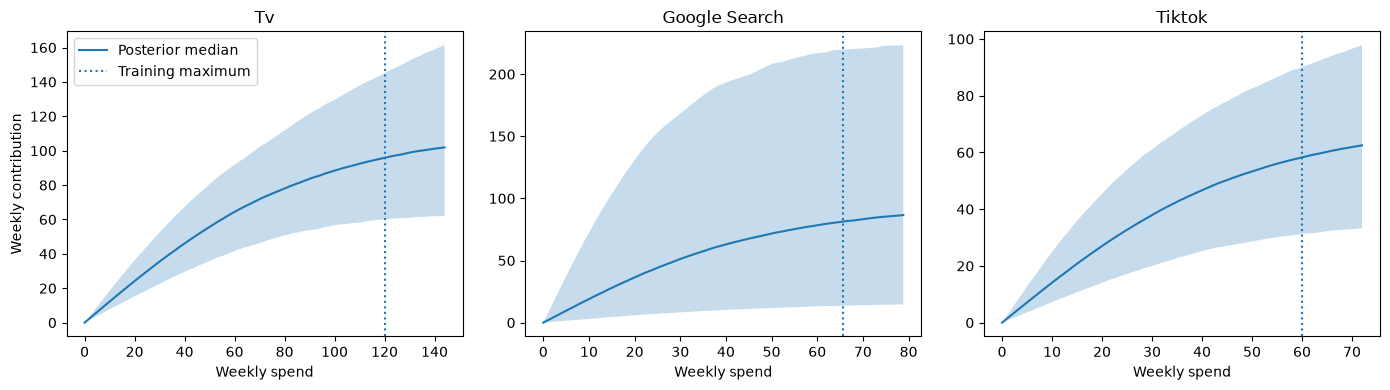

In [4]:
sample = post.stack(
    sample=("chain", "draw")
)

fig, axes = plt.subplots(
    1,
    len(channels),
    figsize=(14, 4),
)

for ax, channel in zip(axes, channels):
    spend = np.linspace(
        0,
        1.2 * df[channel].max(),
        120,
    )

    lam = sample["saturation_lam"].sel(
        channel=channel
    ).values[:, None]

    beta = sample["saturation_beta"].sel(
        channel=channel
    ).values[:, None] * y_scale

    curves = beta * np.tanh(
        lam * spend[None, :]
        / x_scale[channel]
        / 2
    )

    low, median, high = np.quantile(
        curves,
        [0.03, 0.50, 0.97],
        axis=0,
    )

    ax.fill_between(
        spend,
        low,
        high,
        alpha=0.25,
    )

    ax.plot(
        spend,
        median,
        label="Posterior median",
    )

    ax.axvline(
        df[channel].max(),
        linestyle=":",
        label="Training maximum",
    )

    ax.set(
        title=names[channel],
        xlabel="Weekly spend",
    )

axes[0].set_ylabel(
    "Weekly contribution"
)
axes[0].legend()

plt.tight_layout()
plt.show()

## Channel Contributions

The posterior channel contributions show how much revenue the model attributes to each channel over time.

The area chart uses the posterior median contribution for each week.

The table reports total contribution over the training period with a 94% credible interval.

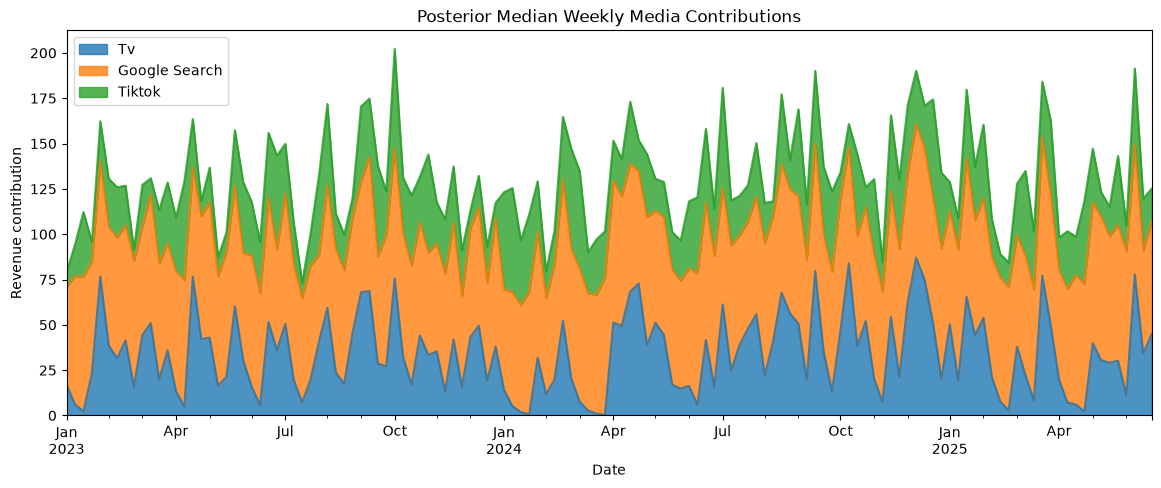

,3%,Median,97%
Tv,2809.1,4454.5,6609.9
Google Search,1412.7,8637.9,25633.9
Tiktok,1976.6,3744.8,6199.2


In [5]:
median = contribution.median(
    ("chain", "draw")
).to_pandas()

median.columns = [
    names[c] for c in channels
]

median.plot.area(
    figsize=(14, 5),
    alpha=0.8,
)

plt.title(
    "Posterior Median Weekly Media Contributions"
)
plt.ylabel(
    "Revenue contribution"
)
plt.xlabel(
    "Date"
)
plt.show()


total = contribution.sum("date")

total_summary = (
    total.quantile(
        [0.03, 0.50, 0.97],
        ("chain", "draw"),
    )
    .transpose("channel", "quantile")
    .to_pandas()
)

total_summary.index = [
    names[c] for c in total_summary.index
]

total_summary.columns = [
    "3%",
    "Median",
    "97%",
]

total_summary.round(1)

## ROAS and Marginal ROAS

Historical ROAS is:


$$
\mathrm{ROAS}_m
=
\frac{\text{Total channel contribution}}
{\text{Total channel spend}}.
$$

Marginal ROAS is estimated by increasing every weekly spend value for one channel by 1%:

$$
\mathrm{mROAS}_m
\approx
\frac{
\text{Contribution at 101% spend}
-
\text{Contribution at current spend}
}{
0.01 \times \text{Total spend}
}.
$$

ROAS measures the average historical return. mROAS estimates the return from an additional dollar near the current spending level.

This simplified calculation only includes contribution within the training window and therefore excludes carryover after the final week.

In [7]:
spend = xr.DataArray(
    df[channels].sum().to_numpy(),
    dims="channel",
    coords={"channel": channels},
)

roas = total / spend


# Current saturation output:
# contribution / beta = tanh(lambda * adstock / 2)
saturation = (
    post["channel_contribution"]
    / post["saturation_beta"]
).clip(
    min=0,
    max=0.999999,
)

# A 1% spend increase also increases adstock by 1%
contribution_plus = (
    post["saturation_beta"]
    * np.tanh(
        1.01 * np.arctanh(saturation)
    )
    * y_scale
)

mroas = (
    contribution_plus - contribution
).sum("date") / (
    0.01 * spend
)


def summarize(x):
    table = (
        x.quantile(
            [0.03, 0.50, 0.97],
            ("chain", "draw"),
        )
        .transpose("channel", "quantile")
        .to_pandas()
    )

    table.index = [
        names[c] for c in table.index
    ]

    table.columns = [
        "3%",
        "Median",
        "97%",
    ]

    return table


pd.concat(
    {
        "ROAS": summarize(roas),
        "mROAS (+1%)": summarize(mroas),
    },
    axis=1,
).round(3)

ROAS               mROAS (+1%)              
                  3% Median    97%          3% Median    97%
Tv             0.700  1.111  1.648       0.536  0.915  1.394
Google Search  0.244  1.489  4.419       0.136  0.800  1.841
Tiktok         0.662  1.253  2.075       0.513  0.974  1.572